In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pyprojroot import here

processed_data = here('data/processed_data')

In [2]:
contracts = pd.read_feather(processed_data / 'contracts2ml.feather', columns = ['contract_year', 'sanctionedB_I_all'])

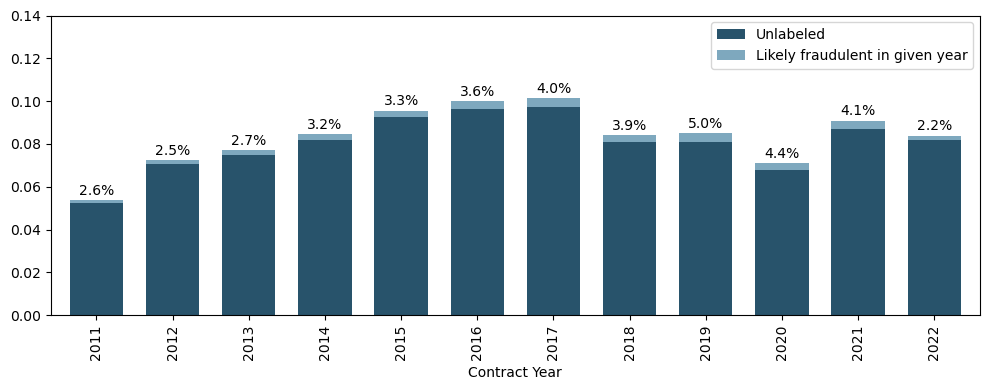

In [3]:
from matplotlib import pyplot as plt

# Define the color palette
colors = ['#28536b', '#7ea8be']

# Count the number of 'sanctioned' for each 'contract_year'
sanctioned_counts = contracts.groupby(['contract_year', 'sanctionedB_I_all']).size().unstack()
sanctioned_counts['unlabeled'] = sanctioned_counts[0] / len(contracts)
sanctioned_counts['possibly_corrupt'] = sanctioned_counts[1] / len(contracts)
sanctioned_counts = sanctioned_counts[['unlabeled', 'possibly_corrupt']]
sanctioned_counts.columns = ['Unlabeled', 'Likely fraudulent in given year']

# Calculate the percentage of 'sanctioned==1' for each 'contract_year'
sanctioned_percentage = contracts.groupby('contract_year')['sanctionedB_I_all'].apply(lambda x: (x == 1).mean()) * 100

# Create the stacked bar plot with a smaller figure size and wider bars
ax = sanctioned_counts.plot(kind='bar', stacked=True, figsize=(10, 4), color=colors, width=0.7)

# Add the percentage to the plot
for i, percentage in enumerate(sanctioned_percentage):
    ax.text(i, sanctioned_counts.sum(axis=1)[sanctioned_percentage.index[i]] + 0.001, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xlabel('Contract Year')
plt.ylim(0, 0.14)

plt.tight_layout()

plt.show()